# PHASE-1


Import Libraries

In [32]:
!pip install joblib

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

import joblib

STEP 1: Load Dataset

In [34]:
df = pd.read_csv("/content/EnviroAI_Hourly_Cleaned_Dataset.csv")
df.head()

,timestamp,pm2.5,pm10,no2,temperature_2m,relative_humidity_2m,wind_speed_10m,ndvi
0,2018-07-04 19:30:00,79.0,251.0,25.1,27.993,85.55127,4.379589,0.376589
1,2018-07-04 19:30:00,79.0,251.0,25.1,27.993,85.55127,4.379589,0.450339
2,2018-07-04 19:45:00,55.0,206.0,24.0,27.993,85.55127,4.379589,0.376589
3,2018-07-04 19:45:00,55.0,206.0,24.0,27.993,85.55127,4.379589,0.450339
4,2018-07-04 20:15:00,55.0,206.0,18.2,28.293,81.35854,0.000000,0.376589




*   Dataset overview



In [35]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (1214801, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214801 entries, 0 to 1214800
Data columns (total 8 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   timestamp             1214801 non-null  object 
 1   pm2.5                 1214801 non-null  float64
 2   pm10                  1214801 non-null  float64
 3   no2                   1214801 non-null  float64
 4   temperature_2m        1214801 non-null  float64
 5   relative_humidity_2m  1214801 non-null  float64
 6   wind_speed_10m        1214801 non-null  float64
 7   ndvi                  1214801 non-null  float64
dtypes: float64(7), object(1)
memory usage: 74.1+ MB


,pm2.5,pm10,no2,temperature_2m,relative_humidity_2m,wind_speed_10m,ndvi
count,1.214801e+06,1.214801e+06,1.214801e+06,1.214801e+06,1.214801e+06,1.214801e+06,1.214801e+06
mean,8.570859e+01,1.676049e+02,2.753916e+01,2.442435e+01,6.320930e+01,9.756640e+00,4.203474e-01
std,6.489979e+01,1.116114e+02,2.565113e+01,8.253599e+00,2.282371e+01,4.682529e+00,9.848763e-02
min,3.000000e-02,7.300000e-01,1.000000e-01,2.143000e+00,6.836951e+00,0.000000e+00,1.783145e-01
25%,3.500000e+01,8.400000e+01,1.130000e+01,1.789300e+01,4.636735e+01,6.618519e+00,3.402063e-01
50%,6.500000e+01,1.450000e+02,2.027000e+01,2.604300e+01,6.611907e+01,8.913181e+00,4.336941e-01
75%,1.230000e+02,2.280000e+02,3.560000e+01,3.039300e+01,8.231330e+01,1.221880e+01,5.087093e-01
max,2.830000e+02,9.960000e+02,4.985000e+02,4.549300e+01,1.000000e+02,3.610245e+01,5.821254e-01


STEP 2:Data Cleaning


2.1  Remove duplicates





In [36]:
df = df.drop_duplicates()

2.2 Remove rows without PM2.5

In [37]:
df = df.dropna(subset=["pm2.5"])

2.3 Select relevant columns

In [38]:
df = df[
    [
        "pm2.5",                 # target
        "pm10",
        "no2",
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
        "ndvi"
    ]
]

STEP 3:Feature & Target Definition

In [39]:
X = df.drop(columns=["pm2.5"],axis=1)
y = df["pm2.5"]

STEP 4:Handle Missing Values

In [40]:
imputer = SimpleImputer(strategy="mean")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

STEP 5:Train–Test Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

STEP 6:Baseline Model (Linear Regression)

In [42]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Metrics

In [43]:
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression
MAE: 25.723114246792765
RMSE: 36.07039471018906
R2: 0.690502815051008


STEP 7:Main Model (Random Forest)

In [44]:
rf = RandomForestRegressor(
    n_estimators=80,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Metrics

In [45]:
print("Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest
MAE: 16.964607694817925
RMSE: 24.52110791897235
R2: 0.8569673809069727


STEP 8:Model Comparison Table

In [46]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,25.723114,36.070395,0.690503
1,Random Forest,16.964608,24.521108,0.856967


STEP 9:Model Validation Plots
Actual vs Predicted

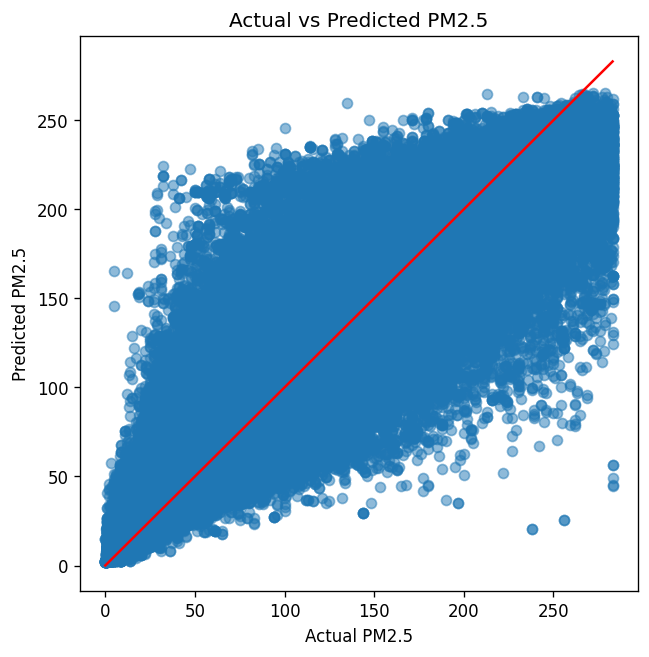

In [47]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5")
plt.show()

Residual Plot

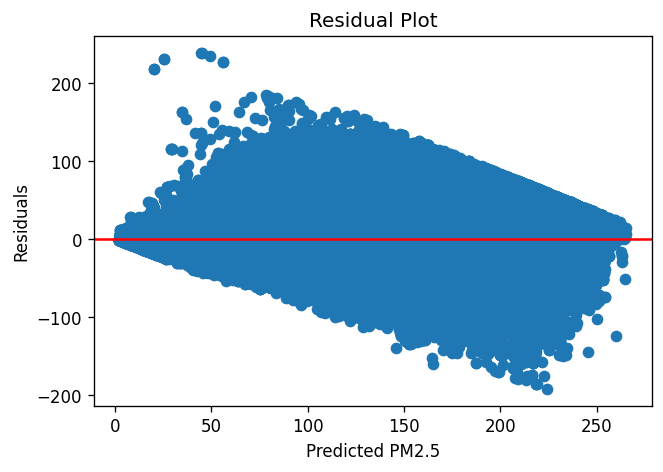

In [48]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(6,4))
plt.scatter(y_pred_rf, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

STEP 10:Feature Importance

pm10                    0.778238
temperature_2m          0.127789
ndvi                    0.037826
no2                     0.028276
relative_humidity_2m    0.019683
wind_speed_10m          0.008187
dtype: float64


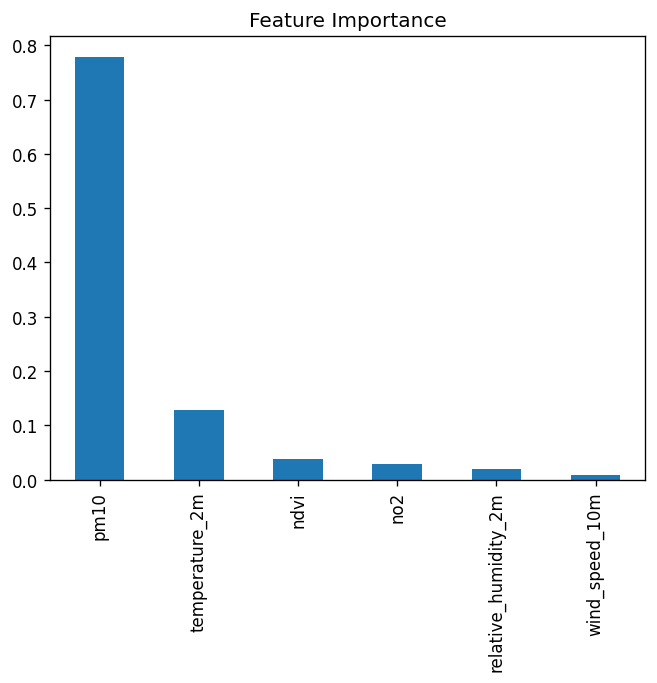

In [49]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

importance.plot(kind="bar", title="Feature Importance")
plt.show()

STEP 11:Save Model

In [50]:
joblib.dump(rf, "enviroai_model.pkl")

['enviroai_model.pkl']

In [51]:
model = joblib.load("enviroai_model.pkl")

print("Model loaded successfully")

Model loaded successfully


In [52]:
prediction = model.predict(X_test.iloc[[0]])

print("Predicted PM2.5:", prediction)

Predicted PM2.5: [207.20385721]


In [53]:
from google.colab import files
files.download("enviroai_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#PHASE-2

Step 1 — Install SHAP

In [54]:
!pip install shap

Step 2 — Import Libraries

In [55]:
import shap

Step 3 — Create SHAP Explainer

In [56]:
plt.rcParams["figure.dpi"] = 120

In [57]:
explainer = shap.TreeExplainer(rf)

Step 4 — Calculate SHAP Values

In [58]:
X_sample = shap.sample(X_test, 500, random_state=42)

shap_values = explainer.shap_values(X_sample)
print("SHAP values generated")

SHAP values generated


In [59]:
joblib.dump(shap_values, "shap_values.pkl")

print("SHAP values saved")

SHAP values saved


Step 5 — SHAP Summary Plot

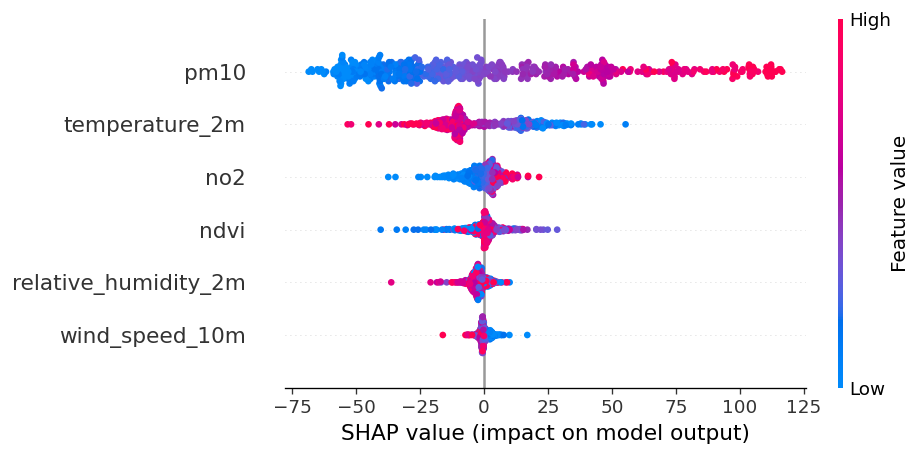

In [60]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.savefig("shap_summary_plot.png", bbox_inches="tight")
plt.show()

Step 6 — Feature Importance Bar Plot

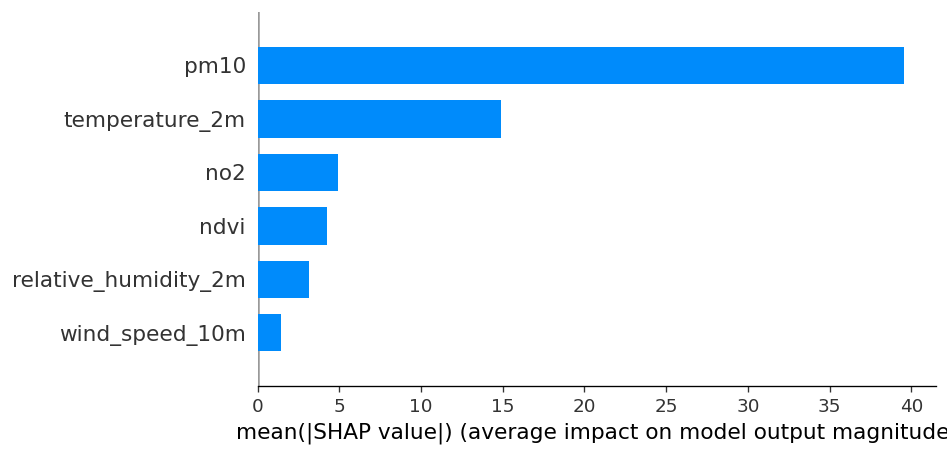

In [61]:
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.savefig("shap_feature_importance_bar.png", bbox_inches="tight")
plt.show()

Step 7 — Dependence Plot

In [64]:
plt.figure()
shap.dependence_plot(
    X_sample.columns[0],
    shap_values,
    X_sample,
    show=False
)
plt.savefig("shap_dependence_plot.png", bbox_inches="tight")
plt.close()

<Figure size 768x576 with 0 Axes>